In [1]:
# Load libraries for data handling, EDA, stats, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %pip install seaborn
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df=pd.read_csv("7_real_estate_prices.csv")
df.head(10)

,property_id,listing_date,property_type,city,neighborhood_tier,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,...,days_on_market,listing_season,market_trend,interest_rate,has_fireplace,has_patio_deck,has_security_system,hoa_fees,sale_price,high_value_property
0,PROP_00000001,17-09-2023,Condo,Denver,Premium,1.33,6,33.5,38,4,...,37,Summer,Stable,6.43,No,Yes,Yes,0.0,822296,Yes
1,PROP_00000002,27-04-2023,Single Family,Seattle,Premium,1.67,6,9.2,85,2,...,5,Fall,Stable,7.15,Yes,Yes,No,307.0,687536,No
2,PROP_00000003,28-11-2023,Single Family,Austin,Average,1.16,6,2.1,98,6,...,7,Fall,Rising,7.48,No,Yes,No,0.0,1207336,Yes
3,PROP_00000004,15-02-2023,Single Family,Austin,Good,0.97,8,2.8,46,4,...,86,Summer,Stable,6.62,Yes,No,No,0.0,938047,Yes
4,PROP_00000005,07-11-2023,Single Family,Atlanta,Premium,2.64,7,10.2,54,3,...,88,Spring,Rising,5.90,Yes,No,No,160.0,691008,No
5,PROP_00000006,27-03-2023,Single Family,Seattle,Developing,3.30,5,1.7,24,1,...,58,Fall,Stable,7.44,No,Yes,No,0.0,566847,No
6,PROP_00000007,15-09-2023,Townhouse,Seattle,Average,0.14,7,0.6,62,4,...,23,Fall,Stable,7.06,Yes,No,No,340.0,916553,Yes
7,PROP_00000008,05-08-2023,Townhouse,Seattle,Good,7.96,6,29.7,25,3,...,37,Winter,Rising,6.52,No,No,No,296.0,844855,Yes
8,PROP_00000009,26-11-2023,Single Family,Seattle,Developing,1.27,7,6.3,49,4,...,17,Spring,Rising,7.45,No,Yes,No,0.0,778269,No
9,PROP_00000010,12-09-2023,Single Family,Austin,Average,0.82,7,4.5,46,5,...,19,Summer,Rising,7.80,Yes,No,No,172.0,962302,Yes


In [3]:
obj_cols = df.select_dtypes(include=['object']).columns
df[obj_cols] = df[obj_cols].replace(r'^\s*$', pd.NA, regex=True)

# Count missing (NaN/NA) per column
missing_counts = df.isna().sum().sort_values(ascending=False)

# Percent missing
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)

# Combine into a single table and show only cols with missing values
missing_table = pd.concat([missing_counts, missing_pct], axis=1)
missing_table.columns = ['missing_count', 'missing_percent']
missing_table = missing_table[missing_table['missing_count'] > 0]

missing_table

C:\Users\SafirudinKM\AppData\Local\Temp\ipykernel_12460\3381032439.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=['object']).columns


,missing_count,missing_percent
renovation_year,8505,56.7
square_feet,750,5.0
hoa_fees,750,5.0


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("7_real_estate_prices.csv")
df['listing_date_raw'] = df['listing_date'].astype(str)

# Choose one parsing approach — replace the line below with A, B, or C
df['listing_date_parsed'] = pd.to_datetime(df['listing_date_raw'], format='%d-%m-%Y', errors='coerce')  # A: DD-MM-YYYY
# df['listing_date_parsed'] = pd.to_datetime(df['listing_date_raw'], dayfirst=True, errors='coerce')   # B: flexible day-first
# df['listing_date_parsed'] = pd.to_datetime(df['listing_date_raw'], format='%Y-%m-%d', errors='coerce')  # C: YYYY-MM-DD

df['listing_date'] = df['listing_date_parsed']
df['listing_year'] = df['listing_date'].dt.year
df['listing_month'] = df['listing_date'].dt.month
df['listing_day'] = df['listing_date'].dt.day

print("Parsed:", df['listing_date'].notna().sum(), "Failed:", df['listing_date'].isna().sum())
if df['listing_date'].isna().any():
    print("Sample problematic raw values:")
    print(df.loc[df['listing_date'].isna(), 'listing_date_raw'].drop_duplicates().head(50))


Parsed: 15000 Failed: 0


In [5]:
df = df.drop(columns=['listing_date_raw'])
df['listing_year'] = df['listing_date'].dt.year
df['listing_month'] = df['listing_date'].dt.month
df['listing_day'] = df['listing_date'].dt.day
df['listing_weekday'] = df['listing_date'].dt.weekday  # 0=Mon
missing_table = pd.concat([df.isna().sum().sort_values(ascending=False),
                           (df.isna().mean()*100).round(2).sort_values(ascending=False)], axis=1)
missing_table.columns = ['missing_count','missing_percent']
missing_table[missing_table['missing_count']>0]
# renovation_year: create missing flag, attempt fill from listing_year & years_since_renovation, then fill sentinel 0
df['renovation_year_missing'] = df['renovation_year'].isna().astype(int)
mask = df['renovation_year'].isna() & df['years_since_renovation'].notna() & df['listing_year'].notna()
df.loc[mask, 'renovation_year'] = (df.loc[mask, 'listing_year'] - df.loc[mask, 'years_since_renovation']).astype(int)
df['renovation_year'] = df['renovation_year'].fillna(0).astype(int)

# square_feet: flag + median impute
df['square_feet_missing'] = df['square_feet'].isna().astype(int)
sq_median = df['square_feet'].median()
df['square_feet'] = df['square_feet'].fillna(sq_median)

# hoa_fees: inspect, then impute 0 if missing means no HOA; else median
print(df['hoa_fees'].describe())
df['hoa_fees_missing'] = df['hoa_fees'].isna().astype(int)
# if domain knowledge: missing => no HOA
df['hoa_fees'] = df['hoa_fees'].fillna(0)
# otherwise: df['hoa_fees'] = df['hoa_fees'].fillna(df['hoa_fees'].median())
df['house_age_calc'] = df['listing_year'] - df['year_built']
df['house_age_calc'] = df['house_age_calc'].clip(lower=0)  # avoid negatives
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['price_per_sqft'] = df['sale_price'] / df['square_feet']
df['has_recent_reno'] = (df['years_since_renovation'] <= 10).astype(int)
df['lot_size_cat'] = pd.cut(df['lot_size_sqft'], bins=[0,2500,7500,1e9], labels=['small','medium','large'])
import numpy as np
df['log_sale_price'] = np.log1p(df['sale_price'])
df['log_price_per_sqft'] = np.log1p(df['price_per_sqft'])
# Optionally cap extreme values: e.g., df = df[df['sale_price'] < df['sale_price'].quantile(0.995)]


count    14250.000000
mean        87.895368
std        133.036807
min       -109.000000
25%          0.000000
50%          0.000000
75%        196.000000
max        673.000000
Name: hoa_fees, dtype: float64


In [6]:
# show negative HOA rows
df[df['hoa_fees'] < 0][['hoa_fees','property_id','property_type','city']].head(20)

# count zeros
(df['hoa_fees'] == 0).sum(), df['hoa_fees'].isna().sum()


(np.int64(9973), np.int64(0))

In [7]:
# Inspect HOA fees problems
import numpy as np

# reload original CSV if you still have it, otherwise use current df but assume original saved as df_orig
# df_orig = pd.read_csv("7_real_estate_prices.csv")  # uncomment if you want fresh copy

# Show count summary and examples
print("HOA summary:")
print(df['hoa_fees'].describe())

print("\nCounts:")
print("Negative HOA count:", (df['hoa_fees'] < 0).sum())
print("Zero HOA count:", (df['hoa_fees'] == 0).sum())
print("Missing HOA count:", df['hoa_fees'].isna().sum())

print("\nSample rows with negative HOA fees:")
display(df.loc[df['hoa_fees'] < 0, ['property_id','hoa_fees','property_type','city','sale_price']].head(20))

print("\nSample rows with zero HOA fees:")
display(df.loc[df['hoa_fees'] == 0, ['property_id','hoa_fees','property_type','city','sale_price']].head(10))


HOA summary:
count    15000.000000
mean        83.500600
std        131.075489
min       -109.000000
25%          0.000000
50%          0.000000
75%        183.000000
max        673.000000
Name: hoa_fees, dtype: float64

Counts:
Negative HOA count: 42
Zero HOA count: 9973
Missing HOA count: 0

Sample rows with negative HOA fees:


,property_id,hoa_fees,property_type,city,sale_price
278,PROP_00000279,-32.0,Single Family,Phoenix,621394
312,PROP_00000313,-20.0,Single Family,Denver,859005
565,PROP_00000566,-10.0,Single Family,Austin,1122582
1012,PROP_00001013,-11.0,Single Family,Atlanta,671920
1081,PROP_00001082,-24.0,Townhouse,Austin,1009822
1298,PROP_00001299,-32.0,Single Family,Seattle,899799
1776,PROP_00001777,-9.0,Single Family,Denver,655904
1922,PROP_00001923,-42.0,Single Family,Phoenix,506183
2252,PROP_00002253,-11.0,Single Family,Denver,641175
3472,PROP_00003473,-3.0,Condo,Denver,589354



Sample rows with zero HOA fees:


,property_id,hoa_fees,property_type,city,sale_price
0,PROP_00000001,0.0,Condo,Denver,822296
2,PROP_00000003,0.0,Single Family,Austin,1207336
3,PROP_00000004,0.0,Single Family,Austin,938047
5,PROP_00000006,0.0,Single Family,Seattle,566847
8,PROP_00000009,0.0,Single Family,Seattle,778269
10,PROP_00000011,0.0,Condo,Seattle,845712
11,PROP_00000012,0.0,Townhouse,Phoenix,808848
12,PROP_00000013,0.0,Condo,Seattle,826289
13,PROP_00000014,0.0,Condo,Austin,902151
14,PROP_00000015,0.0,Single Family,Seattle,660568


In [8]:
# 1) Treat negative HOA values as missing (NaN), add flag
df['hoa_fees_negative_flag'] = (df['hoa_fees'] < 0).astype(int)
df.loc[df['hoa_fees'] < 0, 'hoa_fees'] = np.nan

# 2) Add missing & zero indicators
df['hoa_fees_missing'] = df['hoa_fees'].isna().astype(int)
df['hoa_fees_is_zero'] = (df['hoa_fees'] == 0).astype(int)

# 3) Decide imputation: assume missing (previous negatives) => unknown; fill with 0 if you want to treat as no-HOA,
# or fill with median. We'll keep both options; uncomment preferred one.

# Option A: treat missing as no HOA (fill with 0)
df['hoa_fees_filled'] = df['hoa_fees'].fillna(0.0)

# Option B (alternative): fill with median
# hoa_median = df['hoa_fees'].median()
# df['hoa_fees_filled'] = df['hoa_fees'].fillna(hoa_median)

# 4) Ensure numeric type
df['hoa_fees_filled'] = df['hoa_fees_filled'].astype(float)

# 5) Summary after cleaning
print(df['hoa_fees_filled'].describe())
print("\nCounts:")
print("Negative flagged:", df['hoa_fees_negative_flag'].sum())
print("Missing (before fill):", df['hoa_fees_missing'].sum())
print("Zero count:", (df['hoa_fees_filled'] == 0).sum())

# 6) Show the corrected rows (previous negatives) to verify
print("\nCorrected negative-sample rows (now filled):")
display(df.loc[df['hoa_fees_negative_flag']==1, ['property_id','hoa_fees_filled','property_type','city','sale_price']].head(20))


count    15000.000000
mean        83.574200
std        131.013262
min          0.000000
25%          0.000000
50%          0.000000
75%        183.000000
max        673.000000
Name: hoa_fees_filled, dtype: float64

Counts:
Negative flagged: 42
Missing (before fill): 42
Zero count: 10015

Corrected negative-sample rows (now filled):


,property_id,hoa_fees_filled,property_type,city,sale_price
278,PROP_00000279,0.0,Single Family,Phoenix,621394
312,PROP_00000313,0.0,Single Family,Denver,859005
565,PROP_00000566,0.0,Single Family,Austin,1122582
1012,PROP_00001013,0.0,Single Family,Atlanta,671920
1081,PROP_00001082,0.0,Townhouse,Austin,1009822
1298,PROP_00001299,0.0,Single Family,Seattle,899799
1776,PROP_00001777,0.0,Single Family,Denver,655904
1922,PROP_00001923,0.0,Single Family,Phoenix,506183
2252,PROP_00002253,0.0,Single Family,Denver,641175
3472,PROP_00003473,0.0,Condo,Denver,589354


In [9]:
# 1) Inspect rows with missing square_feet
print("Missing square_feet count:", df['square_feet'].isna().sum())
display(df.loc[df['square_feet'].isna(), ['property_id','property_type','city','sale_price','bedrooms','bathrooms','lot_size_sqft']].head(30))

# 2) Basic stats for square_feet non-missing
print("\nSquare feet summary (non-missing):")
print(df['square_feet'].describe())

# 3) Impute: create missing flag then fill with median
df['square_feet_missing_flag'] = df['square_feet'].isna().astype(int)
sq_median = df['square_feet'].median()
print("\nMedian square_feet:", sq_median)
df['square_feet_filled'] = df['square_feet'].fillna(sq_median).astype(float)

# 4) Optional: if bedrooms/bathrooms exist, check consistency for imputed rows
display(df.loc[df['square_feet_missing_flag']==1, ['property_id','bedrooms','bathrooms','square_feet_filled','sale_price']].head(20))

# 5) Validate no remaining nulls in filled column
print("\nPost-imputation missing count (square_feet_filled):", df['square_feet_filled'].isna().sum())
print(df[['square_feet','square_feet_filled','square_feet_missing_flag']].describe())

# 6) If you'd rather estimate square_feet using a predictive imputer (KNN or Iterative), tell me and I will provide the code.


Missing square_feet count: 0


,property_id,property_type,city,sale_price,bedrooms,bathrooms,lot_size_sqft



Square feet summary (non-missing):
count    15000.000000
mean      2145.734333
std        519.340630
min        248.000000
25%       1812.000000
50%       2145.000000
75%       2481.000000
max       4154.000000
Name: square_feet, dtype: float64

Median square_feet: 2145.0


,property_id,bedrooms,bathrooms,square_feet_filled,sale_price



Post-imputation missing count (square_feet_filled): 0
        square_feet  square_feet_filled  square_feet_missing_flag
count  15000.000000        15000.000000                   15000.0
mean    2145.734333         2145.734333                       0.0
std      519.340630          519.340630                       0.0
min      248.000000          248.000000                       0.0
25%     1812.000000         1812.000000                       0.0
50%     2145.000000         2145.000000                       0.0
75%     2481.000000         2481.000000                       0.0
max     4154.000000         4154.000000                       0.0


In [10]:
import numpy as np

# 1) Derived date features (if not already)
if 'listing_date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['listing_date']):
    df['listing_year'] = df['listing_date'].dt.year
    df['listing_month'] = df['listing_date'].dt.month
    df['listing_weekday'] = df['listing_date'].dt.weekday

# 2) House age (computed) and consistency check with existing house_age column
df['house_age_calc'] = np.where(df['year_built'].notna() & df['listing_year'].notna(),
                                df['listing_year'] - df['year_built'],
                                np.nan)
# Clip negatives to 0 (if year_built > listing_year due to bad data)
df['house_age_calc'] = df['house_age_calc'].clip(lower=0)

# 3) Total rooms and rooms per sqft
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['rooms_per_sqft'] = df['total_rooms'] / df['square_feet_filled']

# 4) Price per sqft and log transforms
df['price_per_sqft'] = df['sale_price'] / df['square_feet_filled']
df['log_sale_price'] = np.log1p(df['sale_price'])
df['log_price_per_sqft'] = np.log1p(df['price_per_sqft'])

# 5) Lot size category
df['lot_size_cat'] = pd.cut(df['lot_size_sqft'], bins=[-1,2500,7500,1e9], labels=['small','medium','large'])

# 6) Recent renovation flag
df['has_recent_reno'] = np.where(df['years_since_renovation'].notna() & (df['years_since_renovation'] <= 10), 1, 0)

# 7) Recompute/fill any remaining missing indicators
df['hoa_fees_filled'] = df['hoa_fees_filled'].fillna(0.0)
df['square_feet_filled'] = df['square_feet_filled'].fillna(df['square_feet_filled'].median())

# 8) Quick summaries
print("Feature summaries:")
print(df[['house_age_calc','total_rooms','rooms_per_sqft','price_per_sqft']].describe().T)

print("\nLot size category distribution:")
print(df['lot_size_cat'].value_counts())

print("\nRecent renovation count:", df['has_recent_reno'].sum())


Feature summaries:
                  count        mean        std         min         25%  \
house_age_calc  15000.0   40.933600  24.337798    0.000000   19.000000   
total_rooms     15000.0    5.761067   1.352960    2.000000    5.000000   
rooms_per_sqft  15000.0    0.002759   0.000647    0.000932    0.002338   
price_per_sqft  15000.0  377.661756  89.842662  124.224507  318.313385   

                       50%         75%          max  
house_age_calc   40.000000   62.000000    83.000000  
total_rooms       6.000000    6.500000    10.000000  
rooms_per_sqft    0.002674    0.003072     0.014113  
price_per_sqft  364.289720  419.292521  1748.487805  

Lot size category distribution:
lot_size_cat
large     5812
medium    5144
small     4044
Name: count, dtype: int64

Recent renovation count: 3860


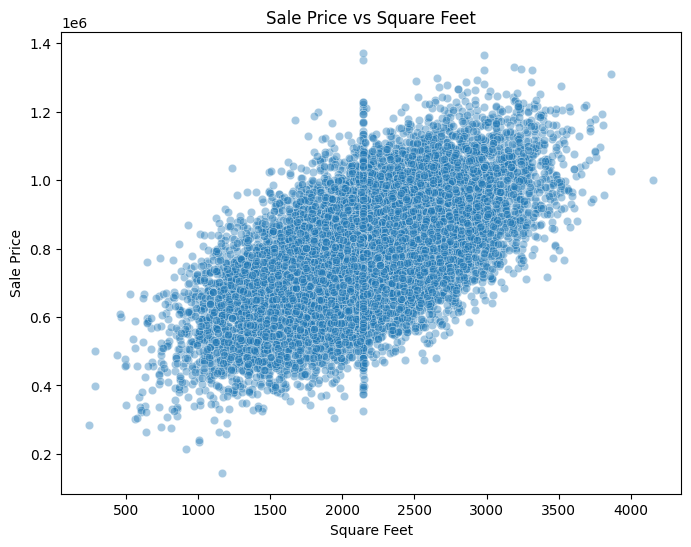

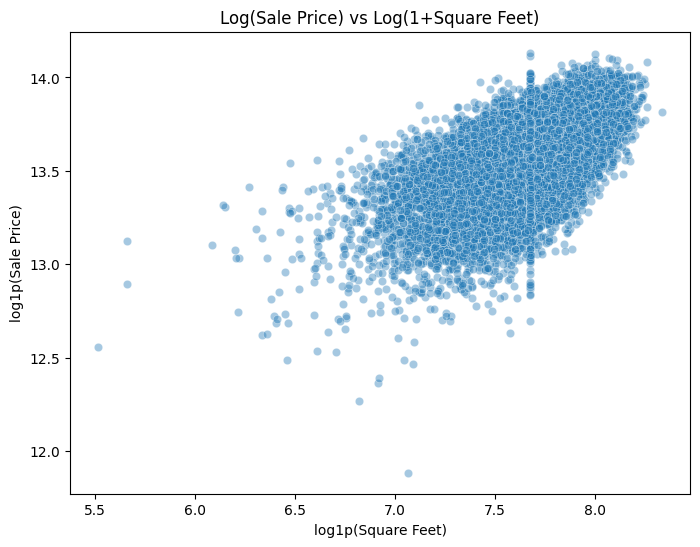

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='square_feet_filled', y='sale_price', data=df, alpha=0.4)
plt.title('Sale Price vs Square Feet')
plt.xlabel('Square Feet')
plt.ylabel('Sale Price')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='log1p(square_feet_filled)' , y='log_sale_price', data=df.assign(**{'log1p(square_feet_filled)': np.log1p(df['square_feet_filled'])}), alpha=0.4)
plt.title('Log(Sale Price) vs Log(1+Square Feet)')
plt.xlabel('log1p(Square Feet)')
plt.ylabel('log1p(Sale Price)')
plt.show()


In [12]:
from scipy import stats
# Pearson (linear)
pearson_r, pearson_p = stats.pearsonr(df['square_feet_filled'], df['sale_price'])
# Spearman (rank)
spearman_rho, spearman_p = stats.spearmanr(df['square_feet_filled'], df['sale_price'])

# Correlation on log scale
pearson_log_r, pearson_log_p = stats.pearsonr(np.log1p(df['square_feet_filled']), df['log_sale_price'])

pearson_r, pearson_p, spearman_rho, spearman_p, pearson_log_r, pearson_log_p


(np.float64(0.6150009379111868),
 np.float64(0.0),
 np.float64(0.5943951580336903),
 np.float64(0.0),
 np.float64(0.6088392520223377),
 np.float64(0.0))

In [13]:
import statsmodels.api as sm
X = sm.add_constant(df['square_feet_filled'])
y = df['sale_price']
model = sm.OLS(y, X).fit()
print(model.summary().tables[1])
Xl = sm.add_constant(np.log1p(df['square_feet_filled']))
yl = df['log_sale_price']
model_log = sm.OLS(yl, Xl).fit()
print(model_log.summary().tables[1])



ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
print(df['renovation_year'])

0        2013
1        2005
2        2008
3        2004
4        1945
         ... 
14995    1969
14996    2005
14997    2005
14998    2017
14999    2017
Name: renovation_year, Length: 15000, dtype: int32
